In [2]:
import os, pathlib

REPO_ROOT = pathlib.Path.home() / "Documents/github/cost_cup"
os.chdir(REPO_ROOT)

print("cwd set to:", os.getcwd())

cwd set to: /Users/ericwiniecke/Documents/github/cost_cup


In [3]:
import os, subprocess, sys

env = os.environ.copy()
env["APP_ENV"] = "aws"  # or "local"

proc = subprocess.Popen([sys.executable, "-m", "dash_app.app"], env=env)
print("Dash starting… open http://127.0.0.1:8050")

Dash starting… open http://127.0.0.1:8050


2026-03-03 18:36:07,176 - INFO - Using AWS database config (APP_ENV=aws). host=database-1.cp82gws4kooz.us-east-2.rds.amazonaws.com db=hockey_stats port=5432


Dash is running on http://0.0.0.0:8050/

 * Serving Flask app 'app'
 * Debug mode: off


2026-03-03 18:36:07,913 - INFO - Dash is running on http://0.0.0.0:8050/

2026-03-03 18:36:07,939 - INFO - WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8050
 * Running on http://10.0.0.253:8050
2026-03-03 18:36:07,939 - INFO - Press CTRL+C to quit


In [7]:
import os
from pathlib import Path

REPO = Path.cwd()
if (REPO / "dash_app").exists() is False and (REPO.parent / "dash_app").exists():
    REPO = REPO.parent
os.chdir(REPO)
print("repo root:", Path.cwd())

repo root: /Users/ericwiniecke/Documents/github/cost_cup


# Cost Cup Project Walkthrough

## 1) What we’re trying to answer
- Why roles/archetypes are useful
- Why ES focus
- What “transition probabilities” mean

## 2) Pipeline map
Raw → resolved identities → player-game → player-season → clustering → transitions + smoothing → dashboard

## 3) Methods (math)
Paste the LaTeX version here.


### Methods (math)

**KMeans archetypes.** We represent each player-season as a feature vector $x_i$ and fit KMeans ($K=3$) within each position group (F/D) by minimizing within-cluster variance:

$$
\min_{\{\mu_k\}_{k=1}^K}\; \sum_{i=1}^{N}\left\|x_i - \mu_{z_i}\right\|^2
$$

To prevent scale dominance across features, we standardize inputs:

$$
\tilde{x}_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

**Rate-based ES features.** To reduce TOI/situation bias, we emphasize even-strength per-60 rates such as:

$$
\text{CF60} = 3600 \cdot \frac{\text{CF}}{\text{TOI}_{ES}}, \quad
\text{CA60} = 3600 \cdot \frac{\text{CA}}{\text{TOI}_{ES}}
$$

**Smoothed transition probabilities.** Let $n_{ij}$ be the number of observed transitions from cluster $i$ to $j$. Using a Dirichlet prior with parameters $\alpha_{ij}$, the posterior mean transition probability is:

$$
\mathbb{E}[p_{ij}\mid \mathbf{n}_i]
=
\frac{n_{ij}+\alpha_{ij}}{\sum_{j'}(n_{ij'}+\alpha_{ij'})}
$$

This shrinkage stabilizes probabilities under sparse data (avoids brittle 0%/100% estimates).

In [5]:
# Optional: import libraries you'll use for visuals
import pandas as pd
import numpy



## 4) Sanity checks we ran (SQL)
/Users/ericwiniecke/Documents/github/cost_cup/sql/sanity/modern



## 5) Edge case: ANA high-CA games
## Edge case: Extreme single-game CA is often a team-environment event (ANA example)

### What this table is (report-ready one sentence)
**ANA games with the highest total team CA (sum of skater CA), showing the top 5 individual player CA values per game.**

- `team_ca` = sum of all ANA skater CA in that game (team pressure / environment proxy)
- `player_ca` = a player’s CA in that same game
- Top 5 players shown per game (so you can see whether the spike is isolated or shared)

### Why we ran this check
A common modeling failure mode is treating extreme single-game defensive events (very high CA) as a pure “player quality” signal.  
This diagnostic lets us separate **player-specific spikes** from **team-level shelling games** where many skaters simultaneously post extreme CA.


### Query (psql-ready)




Interpretation (paste into report)

ANA’s highest team-CA games are major outliers (team_ca in the ~330–380 range), and the largest individual CA values (often high-20s to high-30s) occur inside those same games. Because multiple skaters simultaneously post elevated CA in the same game, these extremes are frequently team-environment / game-state events (“team getting shelled”) rather than isolated evidence that one player is uniquely responsible. Therefore we treat extreme CA as environment-sensitive and interpret it in context (team totals + teammate distribution + game conditions), not as a standalone player-quality signal.

Modeling impact

This edge case directly supports several design choices:
	•	emphasize even-strength and rate-based features
	•	prefer season-level stabilized summaries over single-game extremes
	•	use capping/robust metrics (where applicable) to limit the influence of extreme games
	•	interpret cluster transitions as a mix of role/deployment + team environment + player development


In [15]:
import pandas as pd
from sqlalchemy import text
from db_utils import get_db_engine

engine = get_db_engine()
sql = text("""
WITH team_games AS (
  SELECT f.season, f.game_id, tc.team_code, SUM(f.ca) AS team_ca
  FROM mart.player_game_features_20242025_truth f
  JOIN dim.dim_team_code tc ON tc.team_id = f.team_id
  WHERE f.season = :season AND tc.team_code = :team_code
  GROUP BY 1,2,3
),
ranked_players AS (
  SELECT f.season, f.game_id, f.player_id, f.ca,
         ROW_NUMBER() OVER (PARTITION BY f.season, f.game_id ORDER BY f.ca DESC, f.player_id) AS rn
  FROM mart.player_game_features_20242025_truth f
  JOIN dim.dim_team_code tc ON tc.team_id = f.team_id
  WHERE f.season = :season AND tc.team_code = :team_code
)
SELECT tg.team_code, tg.game_id, tg.team_ca, rp.player_id, rp.ca AS player_ca
FROM team_games tg
JOIN ranked_players rp ON rp.season=tg.season AND rp.game_id=tg.game_id
WHERE rp.rn <= 5
ORDER BY tg.team_ca DESC, tg.game_id, rp.ca DESC;
""")

df = pd.read_sql_query(sql, engine, params={"season": 20242025, "team_code": "ANA"})
df.head(20)

,team_code,game_id,team_ca,player_id,player_ca
0,ANA,2024021038,380.0,8476885,33
1,ANA,2024021038,380.0,8481605,30
2,ANA,2024021038,380.0,8482803,30
3,ANA,2024021038,380.0,8478366,29
4,ANA,2024021038,380.0,8475462,27
5,ANA,2024021033,375.0,8476885,38
6,ANA,2024021033,375.0,8482803,28
7,ANA,2024021033,375.0,8481605,25
8,ANA,2024021033,375.0,8475462,22
9,ANA,2024021033,375.0,8481533,21


### Methods (math)

**KMeans archetypes.** We represent each player-season as a feature vector $x_i$ and fit KMeans ($K=3$):

$$
\min_{\{\mu_k\}_{k=1}^K}\; \sum_{i=1}^{N}\left\|x_i - \mu_{z_i}\right\|^2
$$

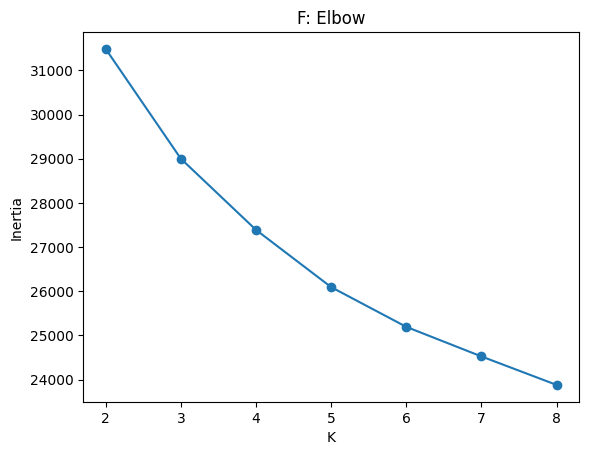

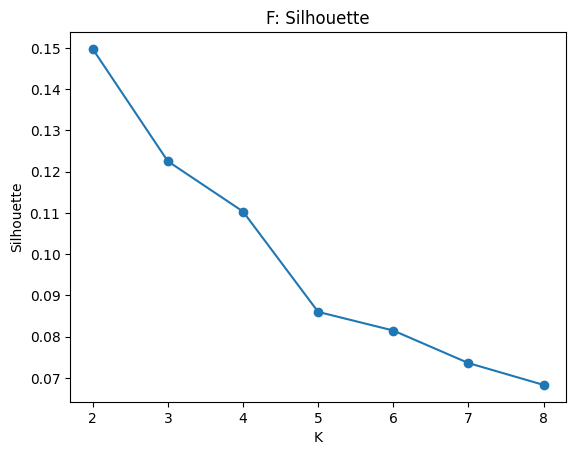

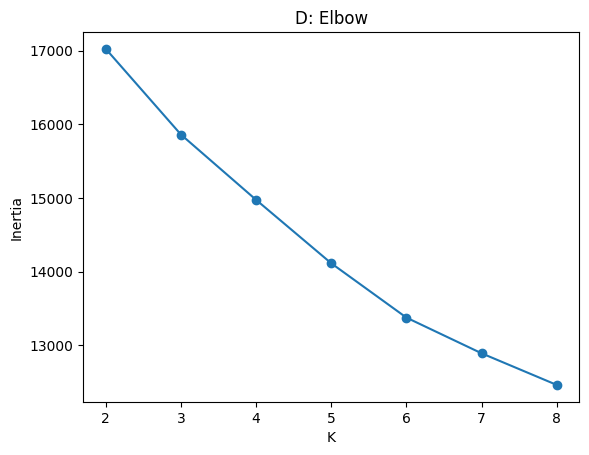

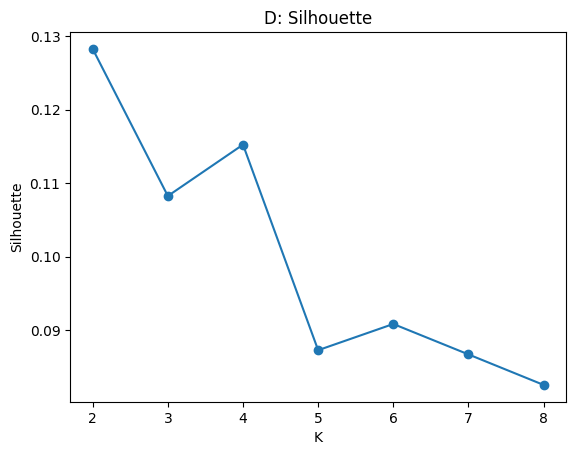

In [13]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from db_utils import get_db_engine

# repo root
REPO = Path.cwd()
if (REPO / "dash_app").exists() is False and (REPO.parent / "dash_app").exists():
    REPO = REPO.parent
os.chdir(REPO)

FEATURES = [
    "toi_per_game","es_share","g60","a60","p60","s60","hit60","blk60",
    "take60","give60","penl60","fo_win_pct","cf60","ca60","cf_percent"
]
TRAIN_SEASONS = {20182019, 20192020, 20202021, 20212022, 20222023}

SRC_SQL = """
SELECT f.*, p.pos
FROM mart.player_season_archetype_features_modern_truth_clean f
JOIN mart.player_season_pos_modern p
  ON p.season=f.season AND p.player_id=f.player_id
WHERE p.pos=:pos
"""

def load_pos_df(pos: str) -> pd.DataFrame:
    eng = get_db_engine()
    try:
        df = pd.read_sql_query(text(SRC_SQL), eng, params={"pos": pos.upper()})
    finally:
        eng.dispose()
    df["fo_win_pct"] = df["fo_win_pct"].fillna(0.5)
    df = df.dropna(subset=FEATURES).copy()
    df_train = df[df["season"].isin(TRAIN_SEASONS)].copy()
    if df_train.empty:
        raise RuntimeError(f"No train rows for pos={pos}")
    return df_train

def k_sweep_plot(pos: str, k_min=2, k_max=8, n_init=50, seed=42):
    df_train = load_pos_df(pos)
    X = df_train[FEATURES].to_numpy(float)
    Xs = StandardScaler().fit_transform(X)

    ks = list(range(k_min, k_max + 1))
    inertias, sils = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=seed)
        labels = km.fit_predict(Xs)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(Xs, labels))

    plt.figure(); plt.plot(ks, inertias, marker="o")
    plt.xlabel("K"); plt.ylabel("Inertia"); plt.title(f"{pos}: Elbow"); plt.show()

    plt.figure(); plt.plot(ks, sils, marker="o")
    plt.xlabel("K"); plt.ylabel("Silhouette"); plt.title(f"{pos}: Silhouette"); plt.show()

k_sweep_plot("F")
k_sweep_plot("D")

In [14]:
print(Path.cwd())

/Users/ericwiniecke/Documents/github/cost_cup


In [ ]:
proc.terminate()